In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM, LeCroyScope, ThorCam
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter, label, center_of_mass

In [26]:
def ShadowImage(atoms, ref, dark, s = 0, sigma0 = 4.849e-13, pixel_size = 3.45e-06, mag_factor = 1.0):
    A_pixel = (pixel_size/mag_factor)**2
    a = atoms.astype(np.float64)
    d = dark.astype(np.float64)
    r = ref.astype(np.float64)
    up = a - d
    # plt.imshow(up)
    # plt.show()
    down = r - d
    # plt.imshow(down)
    # plt.show()
    epsilon = 1e-6
    mask = (down<=0) | (up <=0)
    up[mask] = epsilon
    down[mask] = epsilon

    ratio = up/down
    # plt.imshow(ratio)
    # plt.show()
    
    od = -np.log(ratio)
    od[od<0]=0

    sigma = sigma0/(1 + s)
    
    density = od/(sigma)
    plt.imshow(density)
    plt.colorbar()
    plt.show()

    total_num = np.sum(density * A_pixel)
    
    return total_num

### Establish communication with ThorCam

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [4]:
rm = pyvisa.ResourceManager()
TM = ThorCam.ThorCamManager()
print(rm.list_resources())
print(TM.list_available_serial_numbers())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')
['34101', '35390']


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
cam1 = ThorCam.Zelux("35390")

## power test

In [174]:
pulse_sequence = [["B", 5, 0, 2.2]]  # 20db atten
T = 10
bnc575.clock_set(period = T, mode = "CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_sequence)
bnc575.start_pulses()

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e+01s
Pulses number: N/A
------------------------------------------------------------
[['B', 5, 0, 2.2]]
------------------------------------------------------------
The channel B is set to:
Width: 5.0000e+00s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 2.20

Output timers:
HGFEDCBA
00000010
------------------------------------------------------------


## actual timeing sequence

------------------------------------------------------------
The global clock is set to:
Mode: SING
Period: 1.05e+01s
Pulses number: N/A
------------------------------------------------------------
[['A', 10.0, 0, 2.3], ['F', 1e-05, 10.0, 5], ['B', 5e-05, 10.00005, 2.2]]
------------------------------------------------------------
The channel A is set to:
Width: 1.0000e+01s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 2.30

Output timers:
HGFEDCBA
00000001
------------------------------------------------------------
------------------------------------------------------------
The channel F is set to:
Width: 1.0000e-05s
Delay: 1.0000e+01s
Synchronize to: T0
Out: 5.00

Output timers:
HGFEDCBA
00100000
------------------------------------------------------------
------------------------------------------------------------
The channel B is set to:
Width: 5.0000e-05s
Delay: 1.0000e+01s
Synchronize to: T0
Out: 2.20

Output timers:
HGFEDCBA
00000010
---------------------------------------------

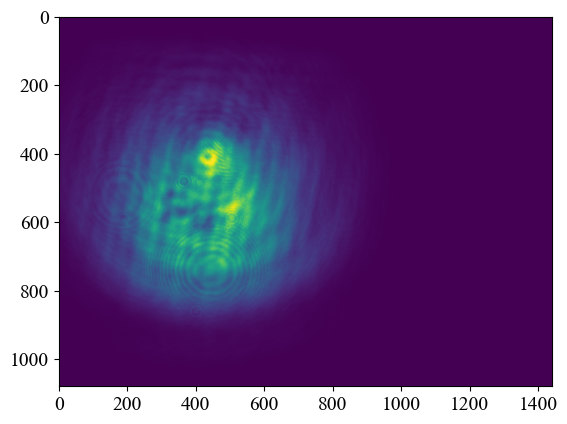

------------------------------------------------------------
The global clock is set to:
Mode: SING
Period: 1.05e+01s
Pulses number: N/A
------------------------------------------------------------
[['F', 1e-05, 0, 5], ['B', 5e-05, 5e-05, 2.2]]
------------------------------------------------------------
The channel F is set to:
Width: 1.0000e-05s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 5.00

Output timers:
HGFEDCBA
00100000
------------------------------------------------------------
------------------------------------------------------------
The channel B is set to:
Width: 5.0000e-05s
Delay: 5.0000e-05s
Synchronize to: T0
Out: 2.20

Output timers:
HGFEDCBA
00000010
------------------------------------------------------------


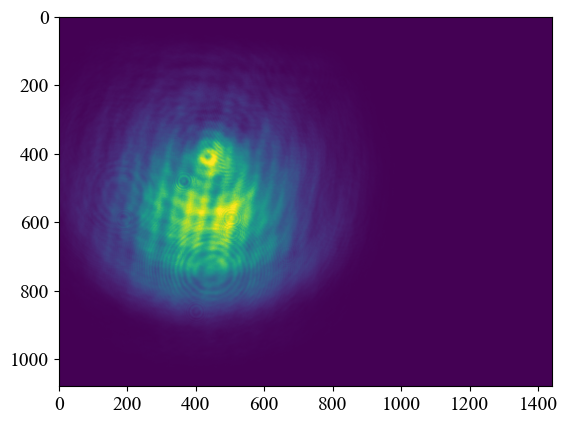

------------------------------------------------------------
The global clock is set to:
Mode: SING
Period: 1.05e+01s
Pulses number: N/A
------------------------------------------------------------
[['F', 1e-05, 0, 5]]
------------------------------------------------------------
The channel F is set to:
Width: 1.0000e-05s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 5.00

Output timers:
HGFEDCBA
00100000
------------------------------------------------------------


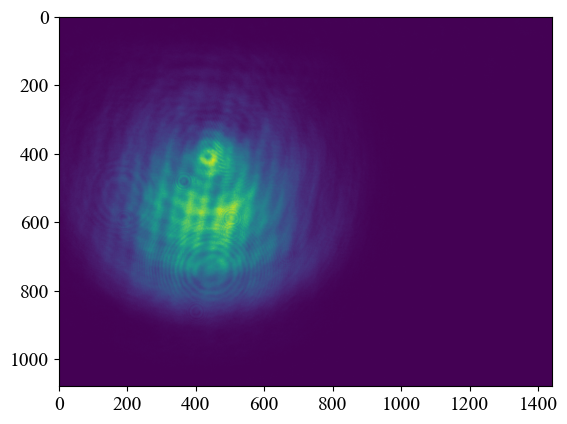

In [179]:
pulse_sequences = [
[["A", 10000e-03, 0, 2.3 ],            # MOT 
 ["F", 10e-06, 0,  5],             # Cam trigger
 # ["B", 100e-06, 40e-06, 2.5],            # 780 EXC (10 dB attenuator connected) 
 ["B", 50e-06, 40e-06, 2.2]                    # 20db atten
],
[["F", 10e-06, 0,  5],             # Cam trigger
 # ["B", 100e-06, 40e-06, 2.5],        # 780 EXC (10 dB attenuator connected) 
 ["B", 50e-06, 40e-06, 2.2]                    # 20db atten
],
[["F", 10e-06, 0,  5],             # Cam trigger
],
]

T = 10500e-3


cam1.set_single_acquisition(exposure_time_us=900, trigger_mode="external")
cam1.arm()
photos = []
for i in range(3):
    bnc575.clock_set(period = T, mode = "SINGLE")

    bnc575.pulse_sequence_setup(pulse_sequences[i])

    bnc575.start_pulses()
    if i == 0:
        time.sleep(T)
    photo = cam1.read_frame()
    photos.append(photo)
    plt.imshow(photo)
    plt.show()



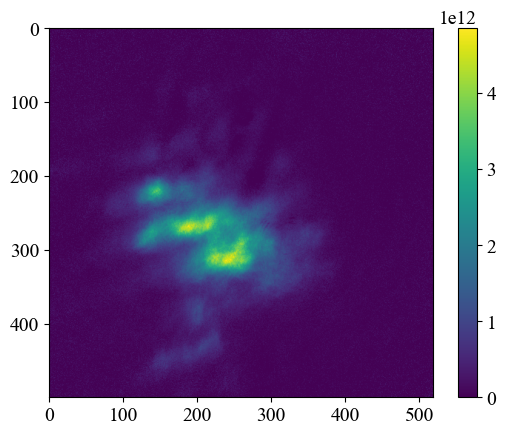

851381.9373288007


In [180]:
atoms = photos[0]
ref = photos[1]
dark = photos[2]

N = ShadowImage(s=0.7,atoms=atoms[300:800,180:700],ref=ref[300:800,180:700], dark=dark[300:800,180:700])
# N = ShadowImage(atoms=atoms[540:570,400:420],ref=ref[540:570,400:420], dark=dark[540:570,400:420])
print(N)

72.0


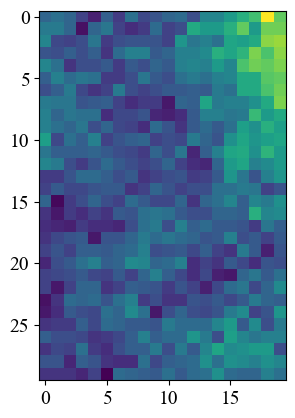

85.0


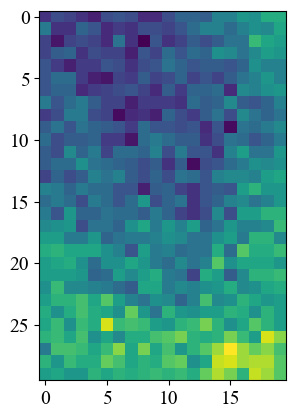

-13.0


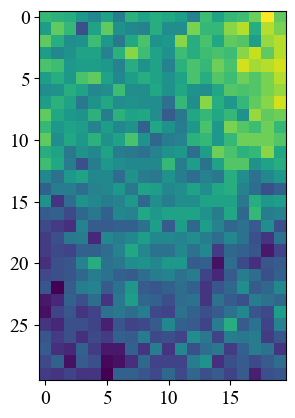

In [177]:
a = atoms[540:570,400:420].astype(np.float64)
plt.imshow(a)
print(a[-1,1])
plt.show()

d = dark[540:570,400:420].astype(np.float64)
plt.imshow(d)
print(d[-1,1])
plt.show()


plt.imshow(a-d)
print((a[-1,1]-d[-1,1]))
plt.show()

In [172]:
a = atoms[540:570,400:420].astype(np.float64)
b = dark[540:570,400:420].astype(np.float64)
a[-1,0]-b[-1,0]

np.float64(-12.0)

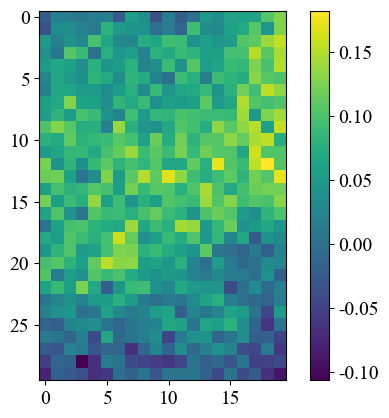

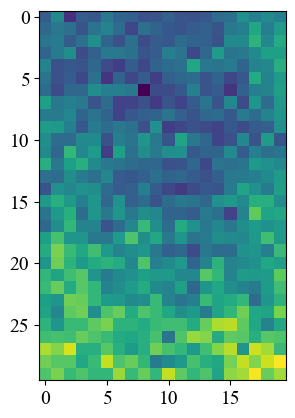

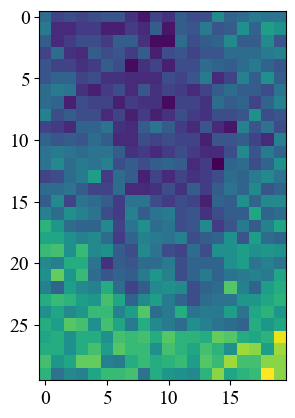

In [12]:
plt.imshow(((atoms[540:570,400:420].astype(np.float64)-dark[540:570,400:420].astype(np.float64))/(ref[540:570,400:420].astype(np.float64)-dark[540:570,400:420].astype(np.float64))))

# print(atoms[540:570,400:420]-dark[540:570,400:420])
plt.colorbar()
plt.show()
plt.imshow(ref[540:570,400:420]-dark[540:570,400:420])
plt.show()
plt.imshow(dark[540:570,400:420])
plt.show()

In [ ]:
detunings = [93.0, 93.7, 94.5, 95.5,96.5]

N_list = [-170705, 10646, -818335,-238144]

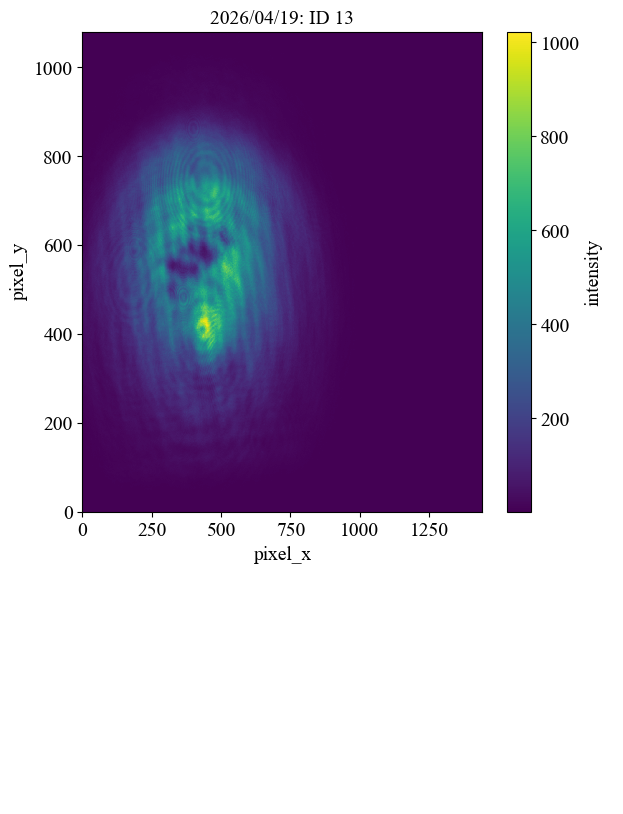

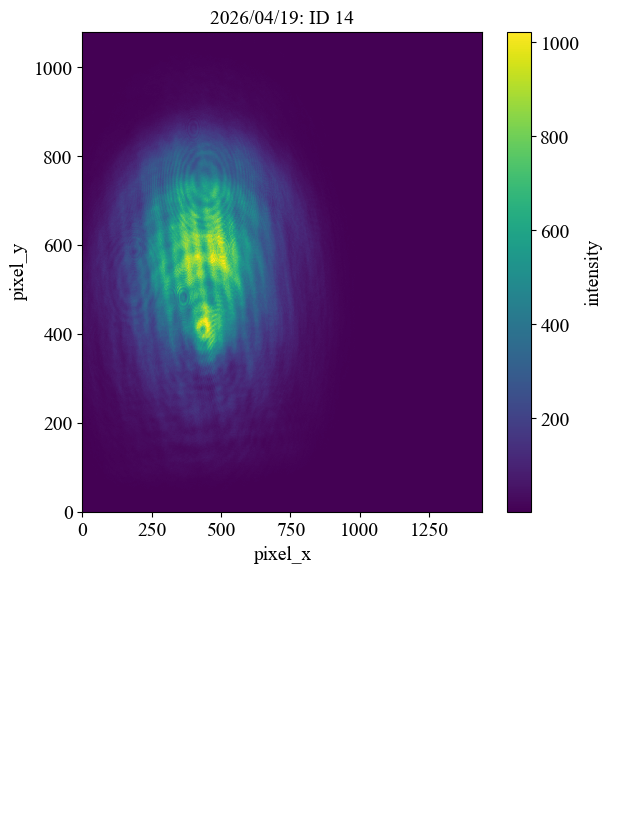

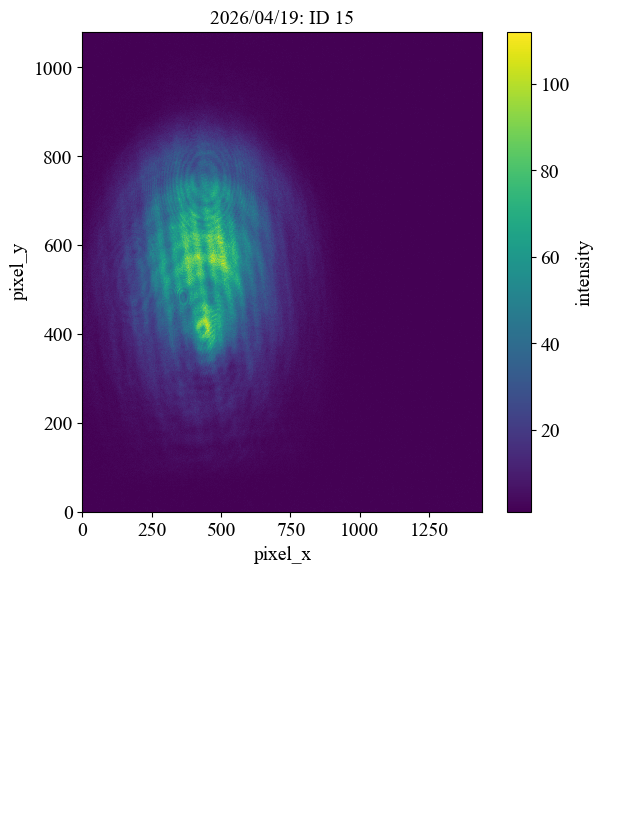

{'id': 15,
 'already_saved': 'successful',
 'png_path': 'X:/migratedData/Rydberg_QIS/data\\2026\\04\\19\\20260419_ID15.png',
 'csv_path': 'X:/migratedData/Rydberg_QIS/data\\2026\\04\\19\\20260419_ID15.csv',
 'hash': 'd8d462f556a95519301d754658377bcc02941590c2f5ff1b30f8b40533497c9a'}

In [166]:
ps.save_frame(atoms)
ps.save_frame(ref)
ps.save_frame(dark)

In [17]:
cam1.set_single_acquisition(exposure_time_us=900, trigger_mode="external")
cam1.disarm()

In [25]:
cam1.arm()

In [30]:
bnc575.start_pulses()

In [34]:
photo = cam1.read_frame()

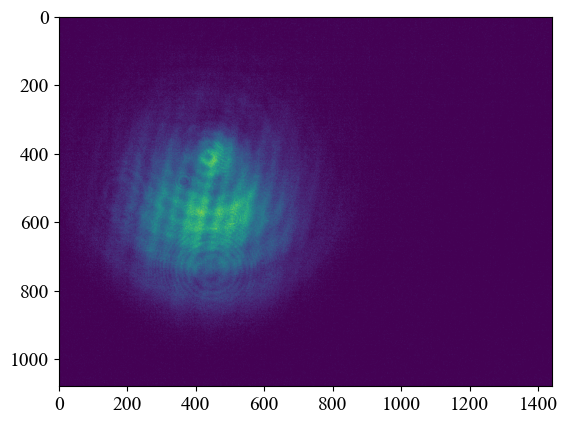

In [35]:
plt.imshow(photo)

### Image readout and analysis, plotting

C:\Users\raithel-lab\AppData\Local\Temp\1\ipykernel_17204\1199114756.py:27: RuntimeWarning: divide by zero encountered in divide
  OD = -np.log(numerator/denominator)
C:\Users\raithel-lab\AppData\Local\Temp\1\ipykernel_17204\1199114756.py:27: RuntimeWarning: invalid value encountered in divide
  OD = -np.log(numerator/denominator)
C:\Users\raithel-lab\AppData\Local\Temp\1\ipykernel_17204\1199114756.py:27: RuntimeWarning: divide by zero encountered in log
  OD = -np.log(numerator/denominator)


Detected MOT center: (y = 548, x = 443)
OD sum (with threshold): 2.143e+03
Estimated atom number: 9.483e+04


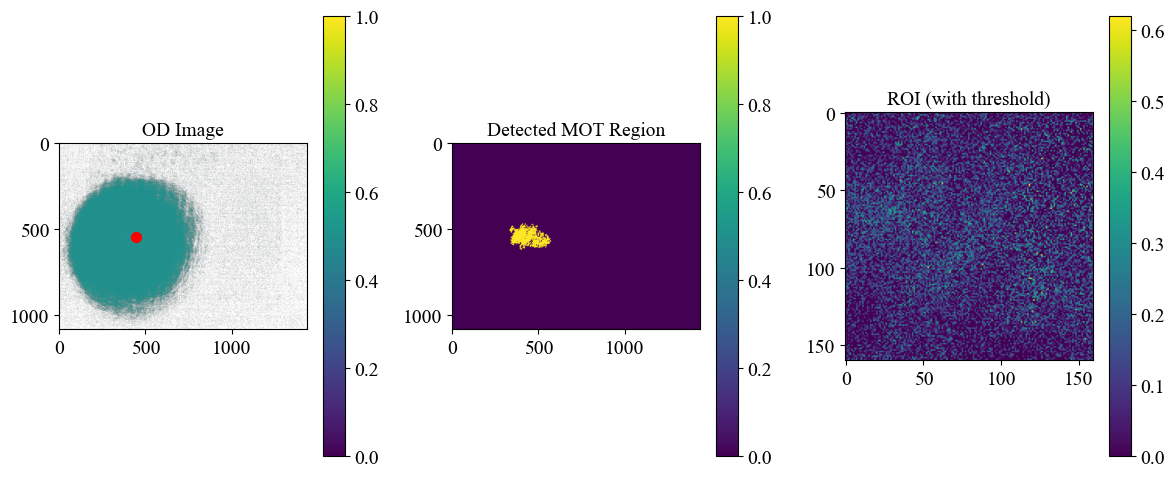

In [57]:
# =========================
# define user parameters
# =========================

epsilon = 1e-6
threshold_OD = 0.05        # threshold to remove noise
blur_sigma = 2             # smoothing for detection
roi_half_size = 80         # pixels around detected center

# =========================
# load stored images
# =========================
atoms = photos[0]
ref = photos[1]
dark = photos[2]

# =========================
# compute optical density (handles cases where log is undefined)
# =========================

numerator = atoms - dark
denominator = ref - dark

numerator[numerator <= 0] = epsilon
denominator[denominator <= 0] = epsilon

OD = -np.log(numerator/denominator)

# =========================
# automatic MOT detection
# =========================

# smooth out to suppress noise
OD_smooth = gaussian_filter(OD, blur_sigma)

# enforce threshold to find MOT cloud
mask = OD_smooth > threshold_OD

# Label connected regions
labeled, num_features = label(mask)

# check if threshold needs to be tuned
if num_features == 0:
    raise RuntimeError("No MOT detected. Adjust threshold.")

# find the largest region (assume MOT is biggest)
sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
largest_label = np.argmax(sizes) + 1

mot_mask = (labeled == largest_label)

# find center of mass
cy, cx = center_of_mass(mot_mask)
cy, cx = int(cy), int(cx)

print(f"Detected MOT center: (y = {cy}, x = {cx})")

# =========================
# define the region of interest (ROI) around the MOT
# =========================

ymin = max(cy - roi_half_size, 0)
ymax = min(cy + roi_half_size, OD.shape[0])
xmin = max(cx - roi_half_size, 0)
xmax = min(cx + roi_half_size, OD.shape[1])

OD_crop = OD[ymin:ymax, xmin:xmax]

# =========================
# perform thresholding
# =========================

OD_crop_thresh = OD_crop.copy()
OD_crop_thresh[OD_crop_thresh < threshold_OD] = 0

#OD_crop_thresh = OD_crop.copy()
#OD_crop_thresh[~mot_mask[ymin:ymax, xmin:xmax]] = 0

# =========================
# calculate atom number
# =========================

pixel_size = 3.45e-06                   # camera pixel size [m]
mag_factor = 1.0                        # magnfication factor from 4f imaging system
A_pixel = (pixel_size/mag_factor)**2    # pixel area [m^2]

lmbda = 0.78e-06                        # probe wavelength [m]
sigma_0 = 3*lmbda**2/(2*np.pi)          # resonant cross section [m^2]

#I_sat = 1.6 # saturation intensity [mW/cm^2]
#I_probe = ?
#s = I_probe/I_sat

s = 0.08                     # saturation parameter (should be around 0.1)
sigma = sigma_0/(1 + s)      # absorption cross section [m^2]
kappa = A_pixel/sigma        # scaling factor for calculating atom number

OD_sum = np.sum(OD_crop_thresh)
N_atoms = kappa * OD_sum     # estimated atom number

print(f"OD sum (with threshold): {OD_sum:.3e}")
print(f"Estimated atom number: {N_atoms:.3e}")

# =========================
# plotting
# =========================
plt.figure(figsize = (12,5))

# original OD image with MOT center identified
plt.subplot(1,3,1)
plt.title("OD Image")
plt.imshow(OD)
plt.scatter(cx, cy, color = 'red', s = 50)
plt.colorbar()

# show detected MOT region
plt.subplot(1,3,2)
plt.title("Detected MOT Region")
plt.imshow(mot_mask)
plt.colorbar()

# show ROI with thresholding
plt.subplot(1,3,3)
plt.title("ROI (with threshold)")
plt.imshow(OD_crop_thresh)
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
photo = cam1.grab_single_frame()

In [ ]:
plt.pcolormesh(photo)